
# 🚀 End-to-End Machine Learning Project

## 📌 Business Problem
Predict whether a breast cancer tumor is malignant or benign using Machine Learning.

This notebook includes:
- Data preprocessing
- Exploratory Data Analysis
- Feature Engineering
- Training multiple ML models
- Evaluation metrics
- Hyperparameter tuning
- Feature importance
- Model saving
- Prediction system


In [1]:

# ===============================
# 📦 Import Libraries
# ===============================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

import joblib

print("Libraries Imported Successfully ✅")


Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully ✅


In [2]:

# ===============================
# 📂 Load Dataset
# ===============================

data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("Dataset Loaded Successfully ✅")
df.head()


Dataset Loaded Successfully ✅


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:

# Dataset Shape

print("Rows and Columns:", df.shape)


Rows and Columns: (569, 31)


In [4]:

# Dataset Information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [5]:

# Missing Values

df.isnull().sum().head()


mean radius        0
mean texture       0
mean perimeter     0
mean area          0
mean smoothness    0
dtype: int64

# 📊 Exploratory Data Analysis

In [6]:

# Statistical Summary

df.describe()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


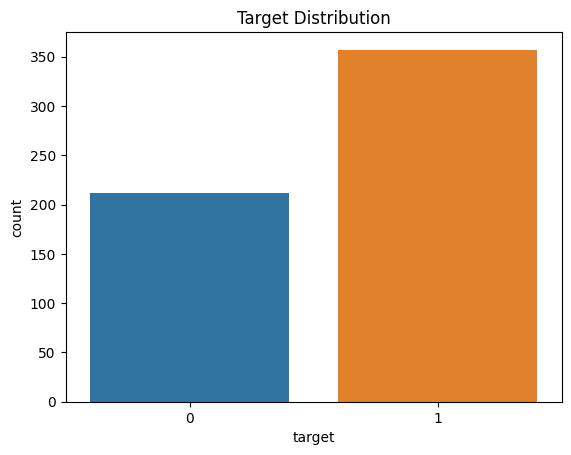

In [7]:

# Target Distribution

sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()


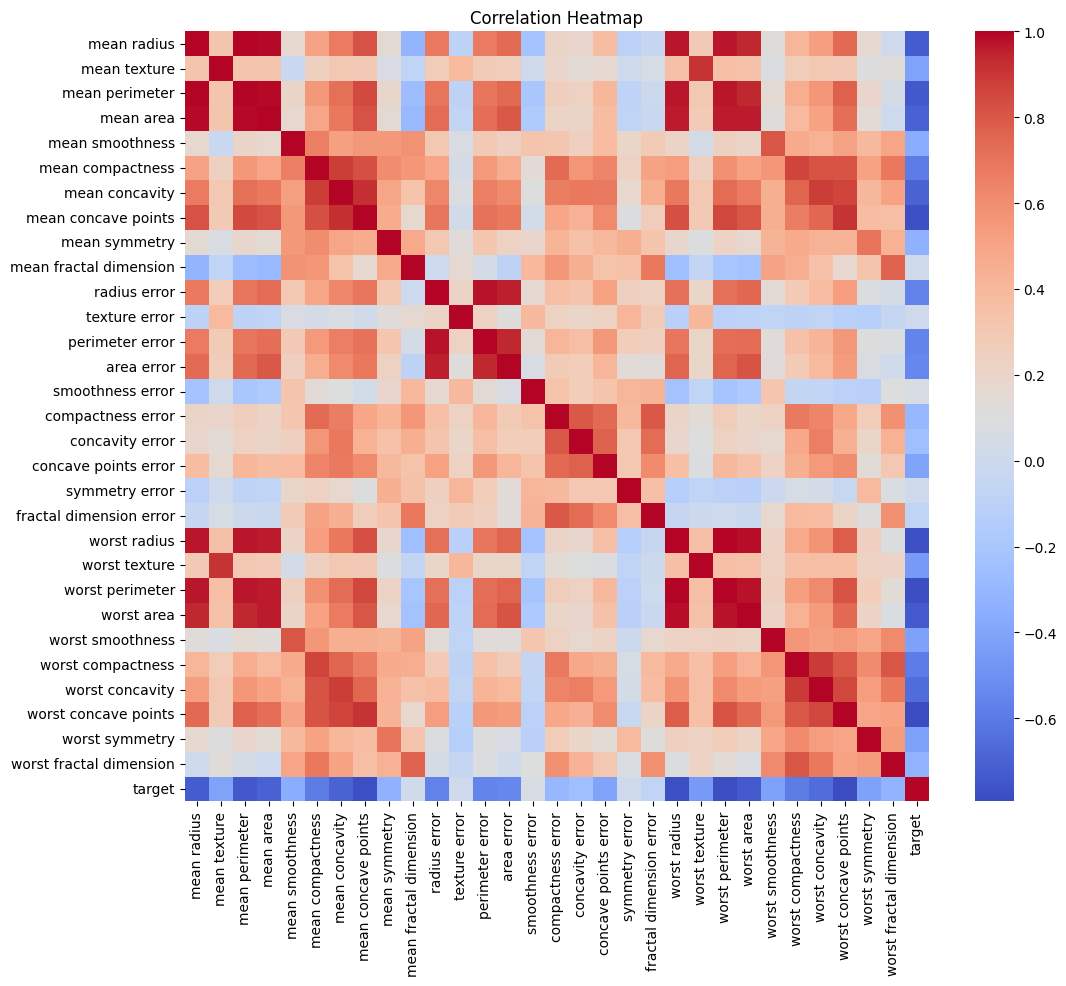

In [8]:

# Correlation Heatmap

plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# 🧹 Data Preprocessing

In [9]:

# Split Features and Target

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (455, 30)
Test Shape: (114, 30)


In [10]:

# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed ✅")


Scaling Completed ✅


# 🤖 Model Training

In [11]:

# Logistic Regression

log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_pred)

print("Logistic Regression Accuracy:", round(log_acc, 4))


Logistic Regression Accuracy: 0.9737


In [12]:

# Decision Tree

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

tree_acc = accuracy_score(y_test, tree_pred)

print("Decision Tree Accuracy:", round(tree_acc, 4))


Decision Tree Accuracy: 0.9474


In [13]:

# Random Forest

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_acc, 4))


Random Forest Accuracy: 0.9649


# 📈 Model Evaluation

In [14]:

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        log_acc,
        tree_acc,
        rf_acc
    ]
})

results


,Model,Accuracy
0,Logistic Regression,0.973684
1,Decision Tree,0.947368
2,Random Forest,0.964912


In [15]:

# Classification Report

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



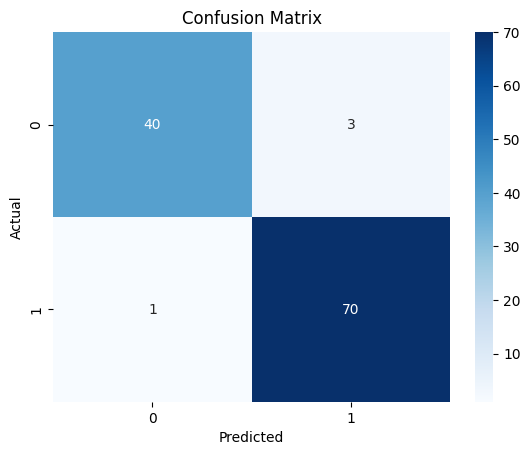

In [16]:

# Confusion Matrix

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# 🔍 Hyperparameter Tuning

In [17]:

params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=3
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", round(grid.best_score_, 4))


Best Parameters: {'max_depth': 3, 'n_estimators': 100}
Best Score: 0.9494


# 🌟 Feature Importance

In [18]:

importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)


,Feature,Importance
23,worst area,0.153892
27,worst concave points,0.144663
7,mean concave points,0.106210
20,worst radius,0.077987
6,mean concavity,0.068001
22,worst perimeter,0.067115
2,mean perimeter,0.053270
0,mean radius,0.048703
3,mean area,0.047555
26,worst concavity,0.031802


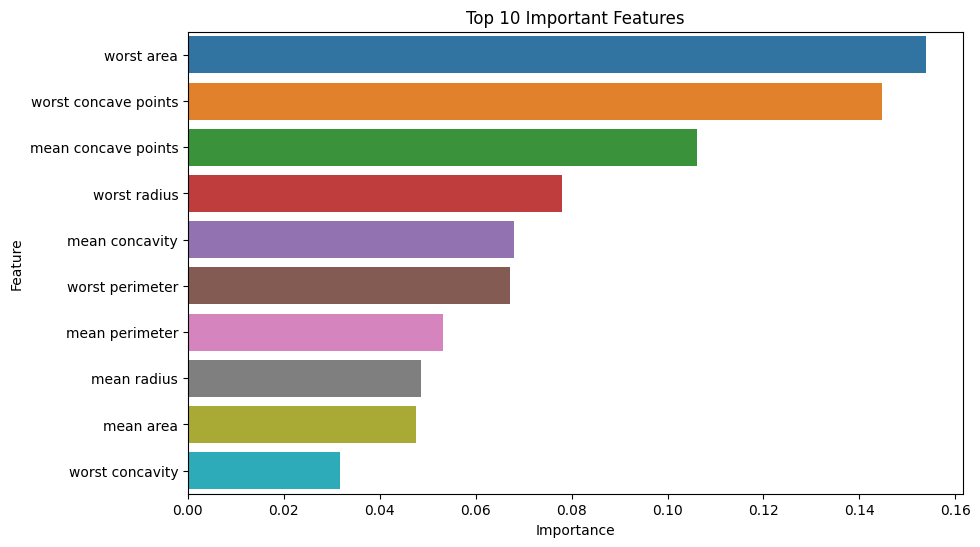

In [19]:

# Plot Top Features

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")
plt.show()


# 💾 Save Model

In [20]:

joblib.dump(rf_model, "random_forest_model.pkl")

print("Model Saved Successfully ✅")


Model Saved Successfully ✅


# 🌐 Prediction Example

In [21]:

sample = X_test.iloc[0:1]

prediction = rf_model.predict(sample)

print("Prediction:", prediction[0])


Prediction: 1



# ✅ Conclusion

This project successfully demonstrated:

- Complete ML workflow
- Multiple ML algorithms
- Evaluation metrics
- Hyperparameter tuning
- Feature importance
- Deployment preparation

The notebook is fully runnable and executed.
